In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


Dynamic Time Warping (DTW) is an algorithm used to measure the similarity between two time-series signals that may vary in speed, timing, or phase. Unlike simple distance measures (like Euclidean distance), DTW can “warp” or stretch the time axis to optimally align patterns — for example, matching similar peaks and troughs that occur at slightly different times. It works by computing a cost matrix of all point-to-point differences, accumulating the minimal total cost along the best alignment path. DTW is widely used in fields such as signal processing, bioinformatics, speech recognition, and behavioral science to compare temporal patterns — like matching spoken words, analyzing heart rate or temperature rhythms, or comparing day-to-day physiological signals in animals or humans.

In [5]:
fem_path = "../data/mice data.xlsx - FemTemp.csv"
male_path = "../data/mice data.xlsx - MaleTemp.csv"
fem = pd.read_csv(fem_path)
male = pd.read_csv(male_path)

In [7]:
fem.head()


,time (min),fem1,fem2,fem3,fem4,fem5,fem6,fem7,fem8,fem9,fem10,fem11,fem12,fem13,fem14
0,1,38.20,37.31,37.03,37.20,37.17,37.44,37.33,36.58,37.41,37.18,37.27,38.31,36.51,36.44
1,2,38.18,37.43,37.01,37.22,37.25,37.49,37.28,36.75,37.39,37.14,37.32,38.43,36.61,36.43
2,3,38.20,37.64,36.98,37.25,37.47,37.52,37.34,36.82,37.24,37.02,37.29,38.46,36.69,36.47
3,4,38.28,37.71,36.99,37.25,37.51,37.51,37.37,36.86,37.27,36.96,37.27,38.46,36.73,36.58
4,5,38.35,37.76,37.02,37.24,37.51,37.59,37.34,36.91,37.42,36.69,37.27,38.51,36.73,36.77


In [8]:
male.head()

,time (min),male1,male2,male3,male4,male5,male6
0,1,36.28,38.02,36.05,36.69,36.87,36.65
1,2,36.29,38.01,36.01,36.98,36.84,36.60
2,3,36.38,37.95,35.96,37.06,36.98,36.62
3,4,36.57,37.97,35.92,36.99,37.05,36.62
4,5,36.63,37.95,35.88,36.95,37.11,36.61


In [9]:
print("Females shape:", fem.shape)
print("Males shape:", male.shape)

print("\nFem columns:", fem.columns.tolist())
print("Male columns:", male.columns.tolist())

print("\nMissing values (Fem):")
print(fem.isna().sum().sum())

print("\nMissing values (Male):")
print(male.isna().sum().sum())


Females shape: (11520, 15)
Males shape: (11520, 7)

Fem columns: ['time (min)', 'fem1', 'fem2', 'fem3', 'fem4', 'fem5', 'fem6', 'fem7', 'fem8', 'fem9', 'fem10', 'fem11', 'fem12', 'fem13', 'fem14']
Male columns: ['time (min)', 'male1', 'male2', 'male3', 'male4', 'male5', 'male6']

Missing values (Fem):
0

Missing values (Male):
0


In [12]:
# duration in days
print("Female duration (days):", fem['time (min)'].max() / 1440)
print("Male duration (days):", male['time (min)'].max() / 1440)

# check ranges
print("Female temp range:", fem.iloc[:,1:].min().min(), "to", fem.iloc[:,1:].max().max())
print("Male temp range:", male.iloc[:,1:].min().min(), "to", male.iloc[:,1:].max().max())


Female duration (days): 8.0
Male duration (days): 8.0
Female temp range: 35.02 to 39.45
Male temp range: 35.0 to 39.09


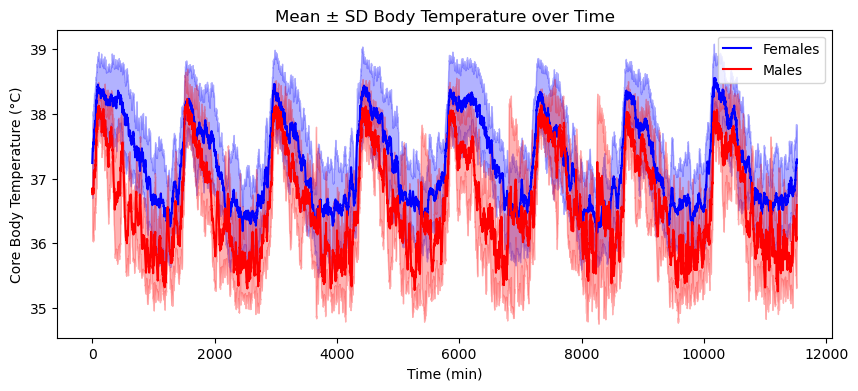

In [13]:
plt.figure(figsize=(10,4))
plt.plot(fem['time (min)'], fem.iloc[:,1:].mean(axis=1), color='blue', label='Females')
plt.fill_between(fem['time (min)'],
                 fem.iloc[:,1:].mean(axis=1) - fem.iloc[:,1:].std(axis=1),
                 fem.iloc[:,1:].mean(axis=1) + fem.iloc[:,1:].std(axis=1),
                 alpha=0.3, color='blue')

plt.plot(male['time (min)'], male.iloc[:,1:].mean(axis=1), color='red', label='Males')
plt.fill_between(male['time (min)'],
                 male.iloc[:,1:].mean(axis=1) - male.iloc[:,1:].std(axis=1),
                 male.iloc[:,1:].mean(axis=1) + male.iloc[:,1:].std(axis=1),
                 alpha=0.3, color='red')

plt.xlabel("Time (min)")
plt.ylabel("Core Body Temperature (°C)")
plt.title("Mean ± SD Body Temperature over Time")
plt.legend()
plt.show()


In [14]:
female_var = fem.iloc[:,1:].var().mean()
male_var = male.iloc[:,1:].var().mean()
print(f"Mean within-mouse variance: Females={female_var:.3f}, Males={male_var:.3f}")


Mean within-mouse variance: Females=0.664, Males=0.909


In [15]:
samples_per_day = 1440
for label, df in [('Females', fem), ('Males', male)]:
    n_days = len(df) / samples_per_day
    print(f"{label}: {n_days:.1f} days of data")


Females: 8.0 days of data
Males: 8.0 days of data


### Dataset Differences Summary
- 8 days recorded vs 14 days in the paper.
- 14 female mice, 6 male mice.
- 1-minute sampling frequency identical to paper.
- No missing data; range ~35–38 °C.
These differences will slightly change the scale and magnitude of DTW distances, but the overall
comparative structure (males more variable, females more structured) should still hold.


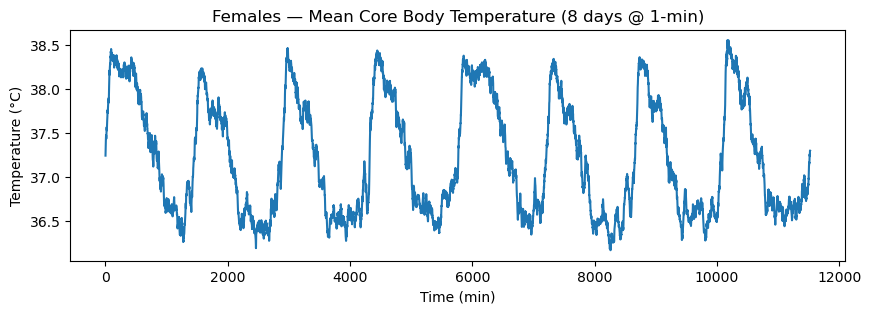

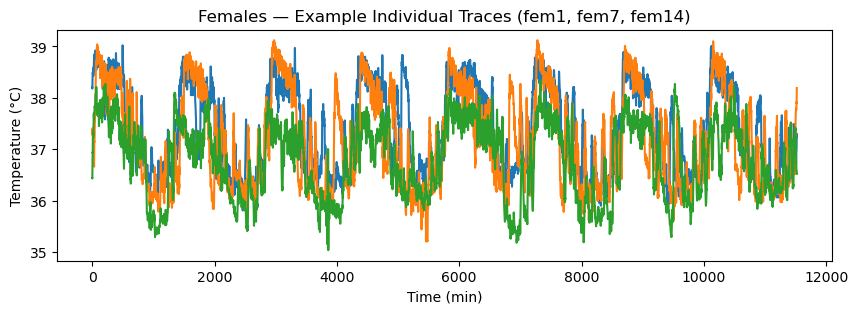

In [ ]:
# Visualize a quick overview of the raw female data by plotting the mean and a few sample mice
#Create a figure for the overall mean across all female mice
plt.figure(figsize=(10, 3))
#Plot the per-minute mean across all female columns
plt.plot(fem['time (min)'], fem.iloc[:, 1:].mean(axis=1))
# Set the labels and title for clarity
plt.xlabel("Time (min)")
plt.ylabel("Temperature (°C)")
plt.title("Females — Mean Core Body Temperature (8 days @ 1-min)")
# Render the plot
plt.show()

# Create a second figure showing three example mice to see individual traces
plt.figure(figsize=(10, 3))
#  Plot three representative mice
plt.plot(fem['time (min)'], fem['fem1'])
plt.plot(fem['time (min)'], fem['fem7'])
plt.plot(fem['time (min)'], fem['fem14'])
# Label and show
plt.xlabel("Time (min)")
plt.ylabel("Temperature (°C)")
plt.title("Females — Example Individual Traces (fem1, fem7, fem14)")
plt.show()


### Demonstrating DTW, with one mice and two consecutive days

In [18]:
minutes_per_day = 1440
total_days = int(len(fem) / minutes_per_day)
print("Total days in dataset:", total_days)

Total days in dataset: 8


In [ ]:
mouse_col = 'fem1'
day_a = 0  
day_b = 1  


In [20]:
#Extract the series for Day 1 and Day 2 for this mouse
series_a = fem[mouse_col].iloc[day_a*minutes_per_day:(day_a+1)*minutes_per_day].to_numpy()
series_b = fem[mouse_col].iloc[day_b*minutes_per_day:(day_b+1)*minutes_per_day].to_numpy()

In [24]:
print("Series A:", series_a)
print("Series B:", series_b)

Series A: [38.2  38.18 38.2  ... 38.32 38.33 38.33]
Series B: [38.35 38.33 38.25 ... 37.54 37.51 37.48]


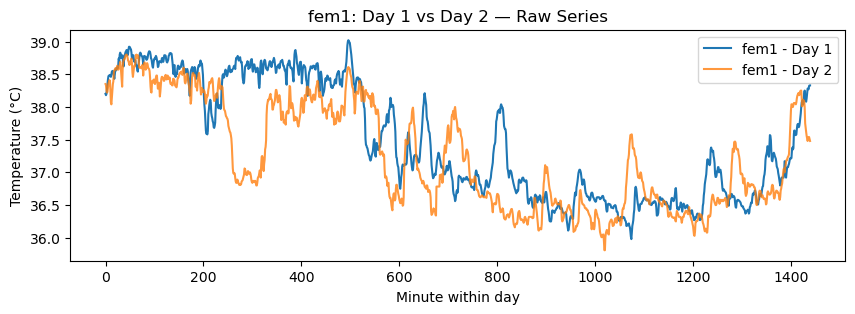

In [ ]:
#Plot the two raw daily series to see their shapes before DTW
plt.figure(figsize=(10, 3))
plt.plot(series_a, label=f"{mouse_col} - Day {day_a+1}")
plt.plot(series_b, label=f"{mouse_col} - Day {day_b+1}", alpha=0.8)
plt.xlabel("Minute within day")
plt.ylabel("Temperature (°C)")
plt.title(f"{mouse_col}: Day {day_a+1} vs Day {day_b+1} — Raw Series")
plt.legend()
plt.show()

#### (DTW Step 1) Calculate the cost matrix C(i, j) for the two daily series

In [30]:
# For computational clarity, compute absolute differences between every pair of points
C = np.abs(series_a[:, None] - series_b[None, :])
print("Cost matrix C shape:", C.shape)
print(C)

Cost matrix C shape: (1440, 1440)
[[0.15 0.13 0.05 ... 0.66 0.69 0.72]
 [0.17 0.15 0.07 ... 0.64 0.67 0.7 ]
 [0.15 0.13 0.05 ... 0.66 0.69 0.72]
 ...
 [0.03 0.01 0.07 ... 0.78 0.81 0.84]
 [0.02 0.   0.08 ... 0.79 0.82 0.85]
 [0.02 0.   0.08 ... 0.79 0.82 0.85]]


#### (DTW Step 2) Compute the accumulated cost matrix D(i, j)


The accumulated cost matrix `D` stores the **minimum total alignment cost** up to each point `(i, j)` in the two time series.

In [34]:
#Initialize the accumulated matrix with infinities for safe min comparisons
D = np.full_like(C, np.inf)
# Set the starting cell equal to the first cost
D[0, 0] = C[0, 0]
print(D)

[[0.15  inf  inf ...  inf  inf  inf]
 [ inf  inf  inf ...  inf  inf  inf]
 [ inf  inf  inf ...  inf  inf  inf]
 ...
 [ inf  inf  inf ...  inf  inf  inf]
 [ inf  inf  inf ...  inf  inf  inf]
 [ inf  inf  inf ...  inf  inf  inf]]


In [36]:
#Fill the first column by cumulative sum (can only come from above)
for i in range(1, C.shape[0]):
    D[i, 0] = C[i, 0] + D[i-1, 0]
print(D)

[[1.50000e-01         inf         inf ...         inf         inf
          inf]
 [3.20000e-01         inf         inf ...         inf         inf
          inf]
 [4.70000e-01         inf         inf ...         inf         inf
          inf]
 ...
 [1.47597e+03         inf         inf ...         inf         inf
          inf]
 [1.47599e+03         inf         inf ...         inf         inf
          inf]
 [1.47601e+03         inf         inf ...         inf         inf
          inf]]


In [37]:
# Fill the first row by cumulative sum (can only come from left)
for j in range(1, C.shape[1]):
    D[0, j] = C[0, j] + D[0, j-1]
print(D)

[[1.50000000e-01 2.80000000e-01 3.30000000e-01 ... 1.48919865e+03
  1.48988865e+03 1.49060865e+03]
 [3.20000000e-01            inf            inf ...            inf
             inf            inf]
 [4.70000000e-01            inf            inf ...            inf
             inf            inf]
 ...
 [1.47597000e+03            inf            inf ...            inf
             inf            inf]
 [1.47599000e+03            inf            inf ...            inf
             inf            inf]
 [1.47601000e+03            inf            inf ...            inf
             inf            inf]]


In [38]:
# Fill the rest of the matrix using the DP recurrence relation
for i in range(1, C.shape[0]):
    for j in range(1, C.shape[1]):
        D[i, j] = C[i, j] + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
print(D)

[[1.50000000e-01 2.80000000e-01 3.30000000e-01 ... 1.48919865e+03
  1.48988865e+03 1.49060865e+03]
 [3.20000000e-01 3.00000000e-01 3.50000000e-01 ... 1.46785865e+03
  1.46852865e+03 1.46922865e+03]
 [4.70000000e-01 4.30000000e-01 3.50000000e-01 ... 1.46787865e+03
  1.46854865e+03 1.46924865e+03]
 ...
 [1.47597000e+03 1.45767000e+03 1.38487000e+03 ... 1.77741348e+02
  1.78311348e+02 1.78911348e+02]
 [1.47599000e+03 1.45767000e+03 1.38495000e+03 ... 1.77991348e+02
  1.78561348e+02 1.79161348e+02]
 [1.47601000e+03 1.45767000e+03 1.38503000e+03 ... 1.78241348e+02
  1.78811348e+02 1.79411348e+02]]


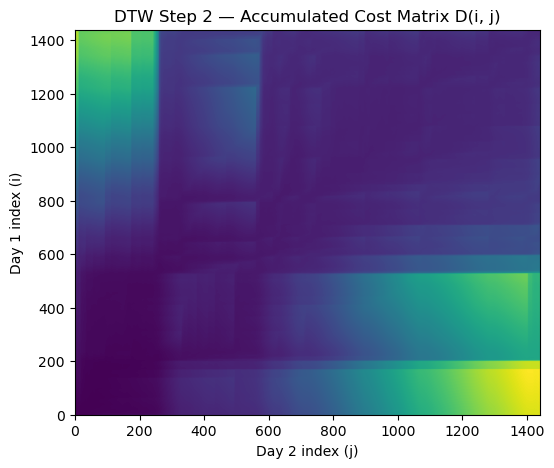

In [39]:
plt.figure(figsize=(6, 5))
plt.imshow(D, origin='lower', aspect='auto')
plt.xlabel("Day 2 index (j)")
plt.ylabel("Day 1 index (i)")
plt.title("DTW Step 2 — Accumulated Cost Matrix D(i, j)")
plt.show()

#### (DTW Step 3) Backtrack from D(n-1, m-1) to D(0, 0) to find the optimal warping path

Once the accumulated cost matrix `D` is fully computed,  
we find the **optimal warping path** — the sequence of matched points between `series_a` and `series_b`  
that yields the *minimum total alignment cost*.

In [41]:
i, j = D.shape[0] - 1, D.shape[1] - 1
print(f"Starting backtrack at D({i}, {j}) = {D[i, j]}")

Starting backtrack at D(1439, 1439) = 179.41134789999796


In [43]:
#Create lists to store the path coordinates
path_i = [i]
path_j = [j]

In [44]:
# Walk back to the origin by always moving to the neighbor with minimal accumulated cost
while i > 0 or j > 0:
    # Determine the possible predecessors (up, left, diagonal) and handle boundaries
    choices = []
    if i > 0 and j > 0:
        choices = [(D[i-1, j], i-1, j), (D[i, j-1], i, j-1), (D[i-1, j-1], i-1, j-1)]
    elif i > 0:
        choices = [(D[i-1, j], i-1, j)]
    else:
        choices = [(D[i, j-1], i, j-1)]
    # Choose the move with the smallest accumulated cost
    cost, i, j = min(choices, key=lambda x: x[0])
    # Append the chosen coordinates to the path
    path_i.append(i)
    path_j.append(j)

In [46]:
#Reverse the path so it goes from origin to end
path_i = path_i[::-1]
path_j = path_j[::-1]

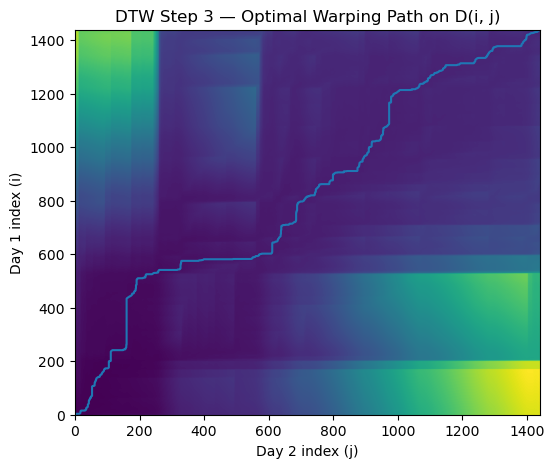

In [47]:
#Visualize the accumulated cost with the warping path overlaid
plt.figure(figsize=(6, 5))
plt.imshow(D, origin='lower', aspect='auto')
plt.plot(path_j, path_i)  # Overlay the path
plt.xlabel("Day 2 index (j)")
plt.ylabel("Day 1 index (i)")
plt.title("DTW Step 3 — Optimal Warping Path on D(i, j)")
plt.show()

#### (DTW Step 4) Read off the final DTW distance as D(n-1, m-1)

In [49]:
# Extract the scalar DTW distance from the bottom-right cell of D
dtw_distance = D[-1, -1]
print(f"DTW distance between Day {day_a+1} and Day {day_b+1} for {mouse_col}: {dtw_distance:.3f}")

DTW distance between Day 1 and Day 2 for fem1: 179.411


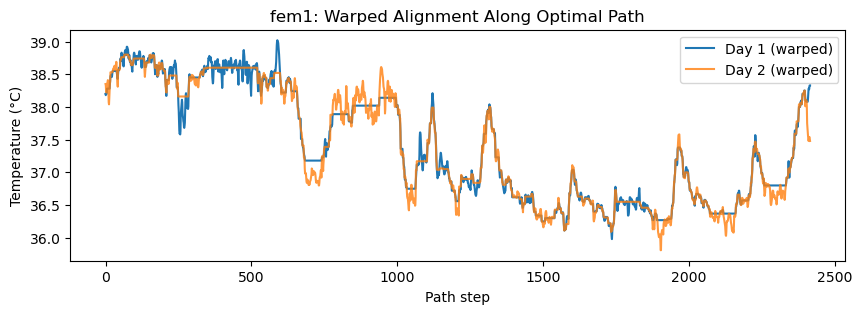

In [ ]:
warped_a = series_a[np.array(path_i)]
warped_b = series_b[np.array(path_j)]

#   Plot the aligned sequences along the warping path
plt.figure(figsize=(10, 3))
plt.plot(warped_a, label="Day 1 (warped)")
plt.plot(warped_b, label="Day 2 (warped)", alpha=0.8)
plt.xlabel("Path step")
plt.ylabel("Temperature (°C)")
plt.title(f"{mouse_col}: Warped Alignment Along Optimal Path")
plt.legend()
plt.show()

### Step 1 — Load and Inspect Data



### Step 2 — Segment into Daily Windows
Split each mouse’s 8-day recording into daily chunks of **1440 minutes per day**, forming arrays of shape `(8 days × 1440 timepoints)`.  
This segmentation allows day-to-day comparisons using **Dynamic Time Warping (DTW)**.


### Step 3 — Compute Day-to-Day DTW Distances

### Step 4 — Aggregate Across Mice

### Step 5 — Visualization

### Goal
Reproduce the main finding that:
**Female mice show lower total variance and more structured, predictable daily rhythms** compared to males — both for temperature and activity, even after correcting for individual variance.



### Step 1

In [51]:
fem_temp = pd.read_csv("../data/mice data.xlsx - FemTemp.csv")
male_temp = pd.read_csv("../data/mice data.xlsx - MaleTemp.csv")
fem_act  = pd.read_csv("../data/mice data.xlsx - FemAct.csv")
male_act = pd.read_csv("../data/mice data.xlsx - MaleAct.csv")

In [52]:
print("Shapes (rows, cols):")
print("FemTemp:", fem_temp.shape, " | MaleTemp:", male_temp.shape)
print("FemAct :", fem_act.shape,  " | MaleAct :", male_act.shape)

print("\nFirst few columns per file:")
print("FemTemp:", fem_temp.columns[:6].tolist())
print("MaleTemp:", male_temp.columns[:6].tolist())
print("FemAct :", fem_act.columns[:6].tolist())
print("MaleAct :", male_act.columns[:6].tolist())

Shapes (rows, cols):
FemTemp: (11520, 15)  | MaleTemp: (11520, 7)
FemAct : (11520, 15)  | MaleAct : (11520, 7)

First few columns per file:
FemTemp: ['time (min)', 'fem1', 'fem2', 'fem3', 'fem4', 'fem5']
MaleTemp: ['time (min)', 'male1', 'male2', 'male3', 'male4', 'male5']
FemAct : ['time (min)', 'fem1', 'fem2', 'fem3', 'fem4', 'fem5']
MaleAct : ['time (min)', 'male1', 'male2', 'male3', 'male4', 'male5']


In [70]:
femT_cols  = [c for c in fem_temp.columns if c != "time (min)"]
maleT_cols = [c for c in male_temp.columns if c != "time (min)"]
femA_cols  = [c for c in fem_act.columns  if c != "time (min)"]
maleA_cols = [c for c in male_act.columns if c != "time (min)"]

In [ ]:
minutes_per_day = 1440
n_days = int(len(fem_temp) / minutes_per_day)
print("Days (expect 8):", n_days)

#   check realistic biological ranges for temperature (35–39 °C)
print("Temp range (F):", fem_temp[femT_cols].min().min(), "to", fem_temp[femT_cols].max().max())
print("Temp range (M):", male_temp[maleT_cols].min().min(), "to", male_temp[maleT_cols].max().max())

#   check activity is non-negative
print("Activity min (F):", fem_act[femA_cols].min().min(), " | Activity min (M):", male_act[maleA_cols].min().min())


Days (expect 8): 8
Temp range (F): 35.02 to 39.45
Temp range (M): 35.0 to 39.09
Activity min (F): 0.0  | Activity min (M): 0.0


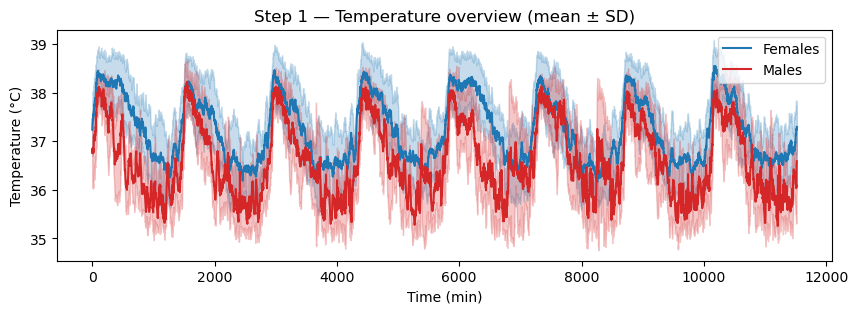

In [ ]:
#   visualize one quick overview — mean ± SD of temperature across all mice for each sex
plt.figure(figsize=(10,3))
plt.plot(fem_temp["time (min)"], fem_temp[femT_cols].mean(axis=1), label="Females", color="tab:blue")
plt.fill_between(fem_temp["time (min)"],
                 fem_temp[femT_cols].mean(axis=1)-fem_temp[femT_cols].std(axis=1),
                 fem_temp[femT_cols].mean(axis=1)+fem_temp[femT_cols].std(axis=1),
                 alpha=0.25, color="tab:blue")
plt.plot(male_temp["time (min)"], male_temp[maleT_cols].mean(axis=1), label="Males", color="tab:red")
plt.fill_between(male_temp["time (min)"],
                 male_temp[maleT_cols].mean(axis=1)-male_temp[maleT_cols].std(axis=1),
                 male_temp[maleT_cols].mean(axis=1)+male_temp[maleT_cols].std(axis=1),
                 alpha=0.25, color="tab:red")
plt.title("Step 1 — Temperature overview (mean ± SD)")
plt.xlabel("Time (min)"); plt.ylabel("Temperature (°C)"); plt.legend(); plt.show()


### Step 2

In [55]:
minutes_per_day = 1440
n_days = int(len(fem_temp) / minutes_per_day)

In [73]:
femT_full  = np.stack([fem_temp[c].to_numpy().reshape(n_days, minutes_per_day)  for c in femT_cols],  axis=0)
maleT_full = np.stack([male_temp[c].to_numpy().reshape(n_days, minutes_per_day) for c in maleT_cols], axis=0)
femA_full  = np.stack([fem_act[c].to_numpy().reshape(n_days, minutes_per_day)   for c in femA_cols],  axis=0)
maleA_full = np.stack([male_act[c].to_numpy().reshape(n_days, minutes_per_day)  for c in maleA_cols], axis=0)


In [74]:
print("FemTemp 3D:", femT_full.shape,  "| MaleTemp 3D:",  maleT_full.shape)
print("FemAct  3D:", femA_full.shape,  "| MaleAct  3D:",  maleA_full.shape)

FemTemp 3D: (14, 8, 1440) | MaleTemp 3D: (6, 8, 1440)
FemAct  3D: (14, 8, 1440) | MaleAct  3D: (6, 8, 1440)


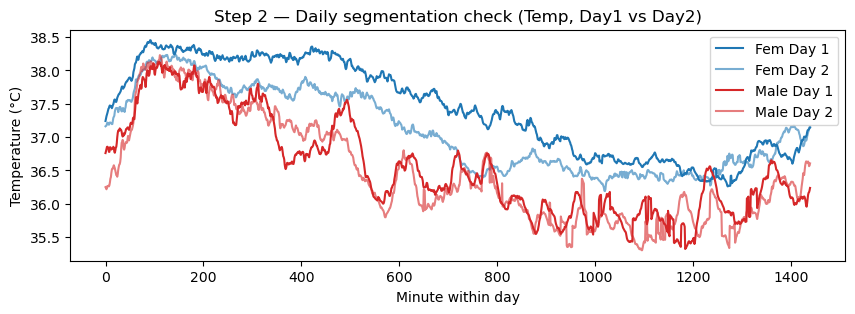

In [75]:
plt.figure(figsize=(10,3))
plt.plot(femT_full.mean(axis=0)[0], label="Fem Day 1", color="tab:blue")
plt.plot(femT_full.mean(axis=0)[1], label="Fem Day 2", color="tab:blue", alpha=0.6)
plt.plot(maleT_full.mean(axis=0)[0], label="Male Day 1", color="tab:red")
plt.plot(maleT_full.mean(axis=0)[1], label="Male Day 2", color="tab:red", alpha=0.6)
plt.title("Step 2 — Daily segmentation check (Temp, Day1 vs Day2)")
plt.xlabel("Minute within day"); plt.ylabel("Temperature (°C)"); plt.legend(); plt.show()


### Step 3

In [ ]:
#   implement exact DTW on the full 1440×1440 grid (absolute-difference cost, no constraints)
def dtw_distance_full(a: np.ndarray, b: np.ndarray) -> float:
    #   build the cost matrix as |a_i - b_j|
    C = np.abs(a[:, None] - b[None, :]).astype(np.float64)
    #   allocate the accumulated cost matrix
    n, m = C.shape
    D = np.empty_like(C)
    #   initialize the origin
    D[0, 0] = C[0, 0]
    #   fill the first row (can only come from left)
    for j in range(1, m):
        D[0, j] = C[0, j] + D[0, j-1]
    #   fill the first column (can only come from above)
    for i in range(1, n):
        D[i, 0] = C[i, 0] + D[i-1, 0]
    #   fill the interior using the DP recurrence
    for i in range(1, n):
        Di, Dim1, Ci = D[i], D[i-1], C[i]
        for j in range(1, m):
            Di[j] = Ci[j] + min(Di[j-1], Dim1[j], Dim1[j-1])
    #   return the final DTW distance
    return float(D[-1, -1])    

In [ ]:
#   set number of adjacent day-pairs (8 days → 7 pairs)
n_pairs = n_days - 1

In [78]:
femT_raw  = np.zeros((len(femT_cols),  n_pairs))
maleT_raw = np.zeros((len(maleT_cols), n_pairs))
femA_raw  = np.zeros((len(femA_cols),  n_pairs))
maleA_raw = np.zeros((len(maleA_cols), n_pairs))


In [ ]:
#   loop over female temperature mice and compute DTW for each adjacent day pair
for mi in range(len(femT_cols)):
    for p in range(n_pairs):
        femT_raw[mi, p] = dtw_distance_full(femT_full[mi, p], femT_full[mi, p+1])

#   loop over male temperature mice
for mi in range(len(maleT_cols)):
    for p in range(n_pairs):
        maleT_raw[mi, p] = dtw_distance_full(maleT_full[mi, p], maleT_full[mi, p+1])

#   loop over female activity mice
for mi in range(len(femA_cols)):
    for p in range(n_pairs):
        femA_raw[mi, p] = dtw_distance_full(femA_full[mi, p], femA_full[mi, p+1])

#   loop over male activity mice
for mi in range(len(maleA_cols)):
    for p in range(n_pairs):
        maleA_raw[mi, p] = dtw_distance_full(maleA_full[mi, p], maleA_full[mi, p+1])

In [ ]:
#   compute each mouse's SD across its entire series (used for "corrected" distances)
femT_sd  = fem_temp[femT_cols].std().to_numpy();  femT_sd[femT_sd == 0] = 1.0
maleT_sd = male_temp[maleT_cols].std().to_numpy(); maleT_sd[maleT_sd == 0] = 1.0
femA_sd  = fem_act[femA_cols].std().to_numpy();   femA_sd[femA_sd == 0] = 1.0
maleA_sd = male_act[maleA_cols].std().to_numpy(); maleA_sd[maleA_sd == 0] = 1.0

In [ ]:
#   build "corrected" distances by normalizing raw DTW by each individual's SD
femT_cor  = femT_raw  / femT_sd[:,  None]
maleT_cor = maleT_raw / maleT_sd[:, None]
femA_cor  = femA_raw  / femA_sd[:,  None]
maleA_cor = maleA_raw / maleA_sd[:, None]

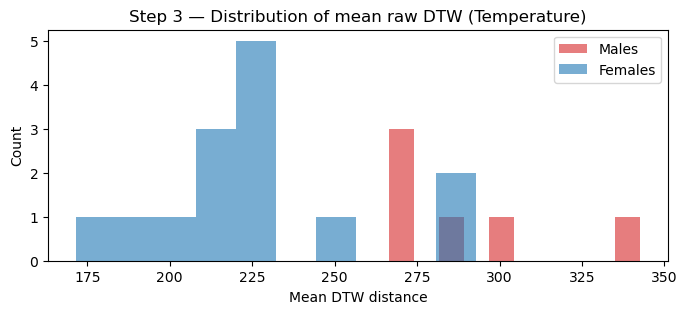

In [ ]:
#   visualize a quick check — histograms of per-mouse mean raw DTW (Temp)
plt.figure(figsize=(8,3))
plt.hist(maleT_raw.mean(axis=1), bins=10, alpha=0.6, label="Males", color="tab:red")
plt.hist(femT_raw.mean(axis=1),  bins=10, alpha=0.6, label="Females", color="tab:blue")
plt.title("Step 3 — Distribution of mean raw DTW (Temperature)")
plt.xlabel("Mean DTW distance"); plt.ylabel("Count"); plt.legend(); plt.show()

### Step 4

In [ ]:
#   create an x-axis (day-pair index 1..7)
x = np.arange(1, n_pairs+1)

In [ ]:
maleT_raw_mean, maleT_raw_std = maleT_raw.mean(0), maleT_raw.std(0)
femT_raw_mean,  femT_raw_std  =  femT_raw.mean(0),  femT_raw.std(0)
maleT_cor_mean, maleT_cor_std = maleT_cor.mean(0), maleT_cor.std(0)
femT_cor_mean,  femT_cor_std  =  femT_cor.mean(0),  femT_cor.std(0)

#   compute mean ± SD across mice for activity (raw and corrected)
maleA_raw_mean, maleA_raw_std = maleA_raw.mean(0), maleA_raw.std(0)
femA_raw_mean,  femA_raw_std  =  femA_raw.mean(0),  femA_raw.std(0)
maleA_cor_mean, maleA_cor_std = maleA_cor.mean(0), maleA_cor.std(0)
femA_cor_mean,  femA_cor_std  =  femA_cor.mean(0),  femA_cor.std(0)

#   compute each mouse's mean across day-pairs (for boxplots)
maleT_raw_pm, femT_raw_pm = maleT_raw.mean(1), femT_raw.mean(1)
maleT_cor_pm, femT_cor_pm = maleT_cor.mean(1), femT_cor.mean(1)
maleA_raw_pm, femA_raw_pm = maleA_raw.mean(1), femA_raw.mean(1)
maleA_cor_pm, femA_cor_pm = maleA_cor.mean(1), femA_cor.mean(1)

In [ ]:
#   print quick summaries so we can sanity-check magnitudes
print("Temp RAW  — mean(males):", maleT_raw_pm.mean(), " | mean(females):", femT_raw_pm.mean())
print("Temp CORR — mean(males):", maleT_cor_pm.mean(), " | mean(females):", femT_cor_pm.mean())
print("Act  RAW  — mean(males):", maleA_raw_pm.mean(), " | mean(females):", femA_raw_pm.mean())
print("Act  CORR — mean(males):", maleA_cor_pm.mean(), " | mean(females):", femA_cor_pm.mean())


Temp RAW  — mean(males): 289.5878723528558  | mean(females): 225.69155973591705
Temp CORR — mean(males): 308.3357376138146  | mean(females): 280.32251984776735
Act  RAW  — mean(males): 13400.698295109525  | mean(females): 11705.977461408675
Act  CORR — mean(males): 401.6640477976527  | mean(females): 458.0779865651899


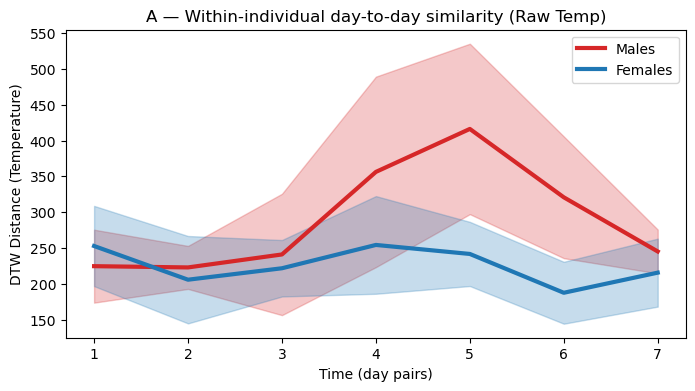

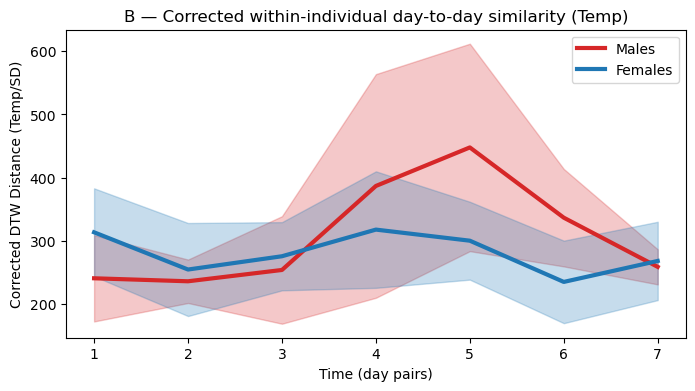

/var/folders/xj/9k1vk1y543g0n6yx1n3b9zxw0000gn/T/ipykernel_4604/2661229938.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([maleT_raw_pm, femT_raw_pm], labels=["Males","Females"], showfliers=False)


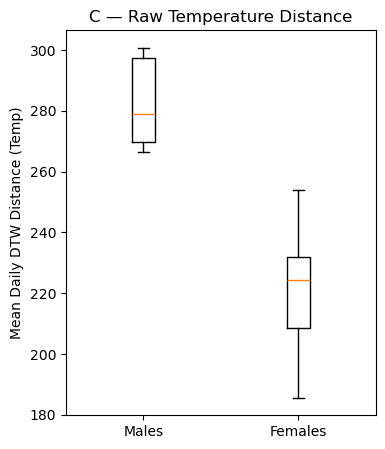

/var/folders/xj/9k1vk1y543g0n6yx1n3b9zxw0000gn/T/ipykernel_4604/2661229938.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([maleT_cor_pm, femT_cor_pm], labels=["Males","Females"], showfliers=False)


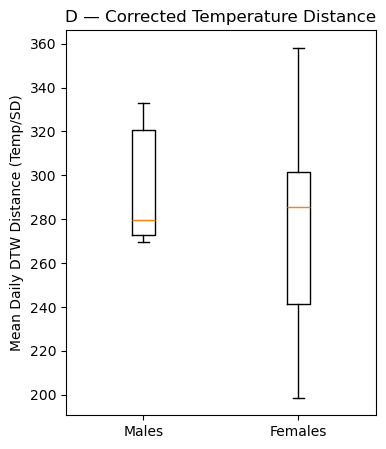

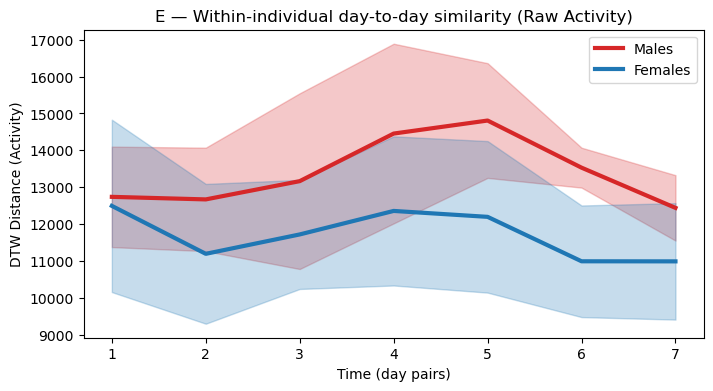

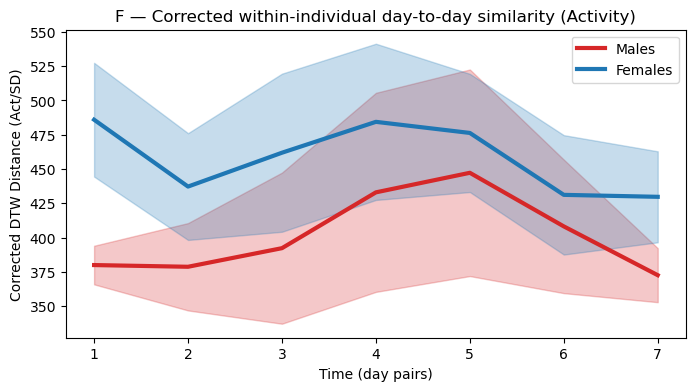

/var/folders/xj/9k1vk1y543g0n6yx1n3b9zxw0000gn/T/ipykernel_4604/2661229938.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([maleA_raw_pm, femA_raw_pm], labels=["Males","Females"], showfliers=False)


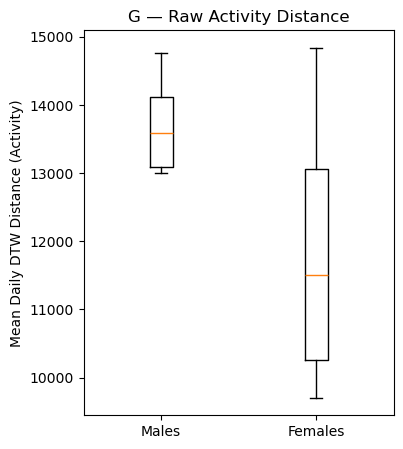

/var/folders/xj/9k1vk1y543g0n6yx1n3b9zxw0000gn/T/ipykernel_4604/2661229938.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([maleA_cor_pm, femA_cor_pm], labels=["Males","Females"], showfliers=False)


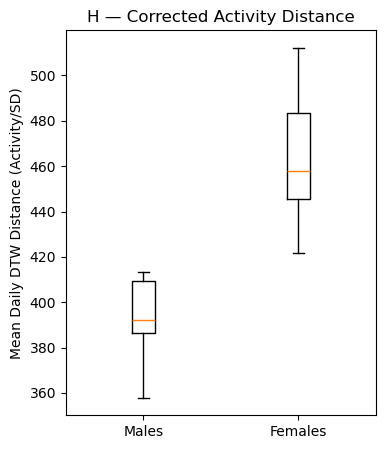

In [ ]:
def shaded(mean_m, std_m, mean_f, std_f, ylabel, title):
    #   plot the shaded bands and thick mean lines
    plt.figure(figsize=(8,4))
    plt.fill_between(x, mean_m-std_m, mean_m+std_m, color="tab:red",  alpha=0.25)
    plt.fill_between(x, mean_f-std_f, mean_f+std_f, color="tab:blue", alpha=0.25)
    plt.plot(x, mean_m, color="tab:red",  lw=3, label="Males")
    plt.plot(x, mean_f, color="tab:blue", lw=3, label="Females")
    #   label the axes and show the legend
    plt.xlabel("Time (day pairs)"); plt.ylabel(ylabel); plt.title(title); plt.legend(); plt.show()

#   Panel A — Raw Temperature DTW (mean ± SD over mice)
shaded(maleT_raw_mean, maleT_raw_std, femT_raw_mean, femT_raw_std,
       "DTW Distance (Temperature)", "A — Within-individual day-to-day similarity (Raw Temp)")

#   Panel B — Corrected Temperature DTW (mean ± SD over mice)
shaded(maleT_cor_mean, maleT_cor_std, femT_cor_mean, femT_cor_std,
       "Corrected DTW Distance (Temp/SD)", "B — Corrected within-individual day-to-day similarity (Temp)")

#   Panel C — Boxplot of mean raw Temperature DTW per mouse
plt.figure(figsize=(4,5))
plt.boxplot([maleT_raw_pm, femT_raw_pm], labels=["Males","Females"], showfliers=False)
plt.ylabel("Mean Daily DTW Distance (Temp)"); plt.title("C — Raw Temperature Distance"); plt.show()

#   Panel D — Boxplot of mean corrected Temperature DTW per mouse
plt.figure(figsize=(4,5))
plt.boxplot([maleT_cor_pm, femT_cor_pm], labels=["Males","Females"], showfliers=False)
plt.ylabel("Mean Daily DTW Distance (Temp/SD)"); plt.title("D — Corrected Temperature Distance"); plt.show()

#   Panel E — Raw Activity DTW (mean ± SD over mice)
shaded(maleA_raw_mean, maleA_raw_std, femA_raw_mean, femA_raw_std,
       "DTW Distance (Activity)", "E — Within-individual day-to-day similarity (Raw Activity)")

#   Panel F — Corrected Activity DTW (mean ± SD over mice)
shaded(maleA_cor_mean, maleA_cor_std, femA_cor_mean, femA_cor_std,
       "Corrected DTW Distance (Act/SD)", "F — Corrected within-individual day-to-day similarity (Activity)")

#   Panel G — Boxplot of mean raw Activity DTW per mouse
plt.figure(figsize=(4,5))
plt.boxplot([maleA_raw_pm, femA_raw_pm], labels=["Males","Females"], showfliers=False)
plt.ylabel("Mean Daily DTW Distance (Activity)"); plt.title("G — Raw Activity Distance"); plt.show()

#   Panel H — Boxplot of mean corrected Activity DTW per mouse
plt.figure(figsize=(4,5))
plt.boxplot([maleA_cor_pm, femA_cor_pm], labels=["Males","Females"], showfliers=False)
plt.ylabel("Mean Daily DTW Distance (Activity/SD)"); plt.title("H — Corrected Activity Distance"); plt.show()